In [2]:
import xarray as xr
import pandas as pd
#from cmocean import cm as cmo 
from pandas.tseries.offsets import DateOffset
import numpy as np
import matplotlib.pyplot as plt
import calendar
from matplotlib.ticker import FormatStrFormatter
import matplotlib.ticker as ticker
plt.rcParams.update({'font.size': 20})
import calendar
import cmocean.cm as cmo
from metpy.interpolate import cross_section

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
### Bathy
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]

### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")

### CMA
ds = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/All/new_all_CORA_MEOP_ARGO_2024.nc")
index = np.where(ds.time > pd.to_datetime("2023-12-31"))[0]
ds = ds.isel(uid=slice(0, index[0]))

### Individual datasets for observations 
ds_CORA = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/All/new_all_CORA_2024.nc")
ds_MEOP = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/All/all_MEOP_2024.nc")
ds_ARGO = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/All/all_ARGO_2024.nc")

ds_CMA = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_gridded.nc")

ds_MEOP = ds_MEOP.where(ds_MEOP.time < pd.to_datetime("2024-01-01"), drop=True)
ds_ARGO = ds_ARGO.where(ds_ARGO.time < pd.to_datetime("2024-01-01"), drop=True)
ds_CORA = ds_CORA.where(ds_CORA.time < pd.to_datetime("2024-01-01"), drop=True)

In [4]:
ds_cut_ARGO = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/ARGO_gridded.nc")
ds_cut_CORA = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CORA_gridded.nc")
ds_cut_MEOP = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/MEOP_gridded.nc")
ds_cut_CORA = xr.merge([ds_cut_CORA,ds_cut_ARGO])

In [5]:
def grid_profile_counts(ds, nb_bins=39, end_date="2023-12-31"):
    # We grid the data and count how many profiles we have per grid cell
    df0 = ds.mld.to_dataframe().rename(columns={"LONGITUDE": "longitude", "LATITUDE": "latitude"})

    cut_lat_label = pd.cut(df0["latitude"], nb_bins)
    cut_lon_label = pd.cut(df0["longitude"], nb_bins)

    bins_dt = pd.date_range(
        start=df0["time"].min() + DateOffset(months=-1),
        end=df0["time"].max(),
        freq="ME"
    )
    bins_str = bins_dt.astype(str).values
    cut_time_label = pd.cut(df0["time"], bins=bins_dt)

    df_cut_label = df0.drop(["latitude", "longitude", "time"], axis=1)
    df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).count()

    lat_mid = pd.IntervalIndex(df_cut_label.index.get_level_values("latitude")).mid.unique()
    lon_mid = pd.IntervalIndex(df_cut_label.index.get_level_values("longitude")).mid.unique()
    time_mid = pd.IntervalIndex(df_cut_label.index.get_level_values("time")).mid.unique()

    df_cut_label.index = df_cut_label.index.set_levels(time_mid.values, level=0)
    df_cut_label.index = df_cut_label.index.set_levels(lon_mid, level=1)
    df_cut_label.index = df_cut_label.index.set_levels(lat_mid.values, level=2)

    df_cut = df_cut_label.copy()
    df_cut.replace(0, np.nan, inplace=True)

    ds_cut = df_cut.to_xarray()
    ds_cut["latitude"] = sorted(lat_mid)
    ds_cut["longitude"] = sorted(lon_mid)
    ds_cut["time"] = time_mid

    df = ds_cut.to_dataframe()
    df["strat"] = df.mld
    df["ist"] = df.mld

    ds_count = ds_cut.sel(time=slice(ds_cut.time.min(), pd.to_datetime(end_date)))

    return ds_count

# usage
ds_count_ARGO = grid_profile_counts(ds_ARGO)
ds_count_CORA = grid_profile_counts(ds_CORA)
ds_count_MEOP = grid_profile_counts(ds_MEOP)
ds_count_CORA = xr.merge([ds_count_CORA,ds_count_ARGO])
ds_count = grid_profile_counts(ds)

/tmp/ipykernel_722541/992452165.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).count()
/tmp/ipykernel_722541/992452165.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).count()
/tmp/ipykernel_722541/992452165.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence t

In [6]:
hist_data = ds_count.sum(["latitude","longitude"]).groupby("time.year").sum()
hist_data_month = ds_count.sum(["latitude","longitude"]).groupby("time.month").sum()

In [15]:
ds_coef = ds_CMA.mean("time").metpy.parse_cf().squeeze()
start_coef =(ds_coef.longitude[2],ds_coef.latitude[2])
end_coef = (ds_coef.longitude[6],ds_coef.latitude[6])
cross_coef = cross_section(ds_coef, start_coef, end_coef)
### First cross section
# start_c =(70,-51.5)
# end_c = (75.5,-48)
# cross_c = cross_section(ds_coef, start_c[::-1], end_c[::-1])
# cross_coef = cross_section(ds_coef.mld, start_c[::-1], end_c[::-1])

### Second cross section
start_c1 =(72,-52.5)
end_c1 = (79,-47)
cross_c1 = cross_section(ds_coef, start_c1[::-1], end_c1[::-1])
cross_coef1 = cross_section(ds_coef.mld, start_c1[::-1], end_c1[::-1])


# ### Third cross section
# start_c2 =(74,-54)
# end_c2 = (79.5,-50.5)
# cross_c2 = cross_section(ds_coef, start_c2[::-1], end_c2[::-1])
# cross_coef2 = cross_section(ds_coef.mld, start_c2[::-1], end_c2[::-1])


### Elevation cross section
# cross_el = cross_section(-elevation.to_dataset().metpy.parse_cf(),start_c[::-1], end_c[::-1])
cross_el1 = cross_section(-elevation.to_dataset().metpy.parse_cf(),start_c1[::-1], end_c1[::-1])
# cross_el2 = cross_section(-elevation.to_dataset().metpy.parse_cf(),start_c2[::-1], end_c2[::-1])

Could not find variable corresponding to the value of grid_mapping: crs


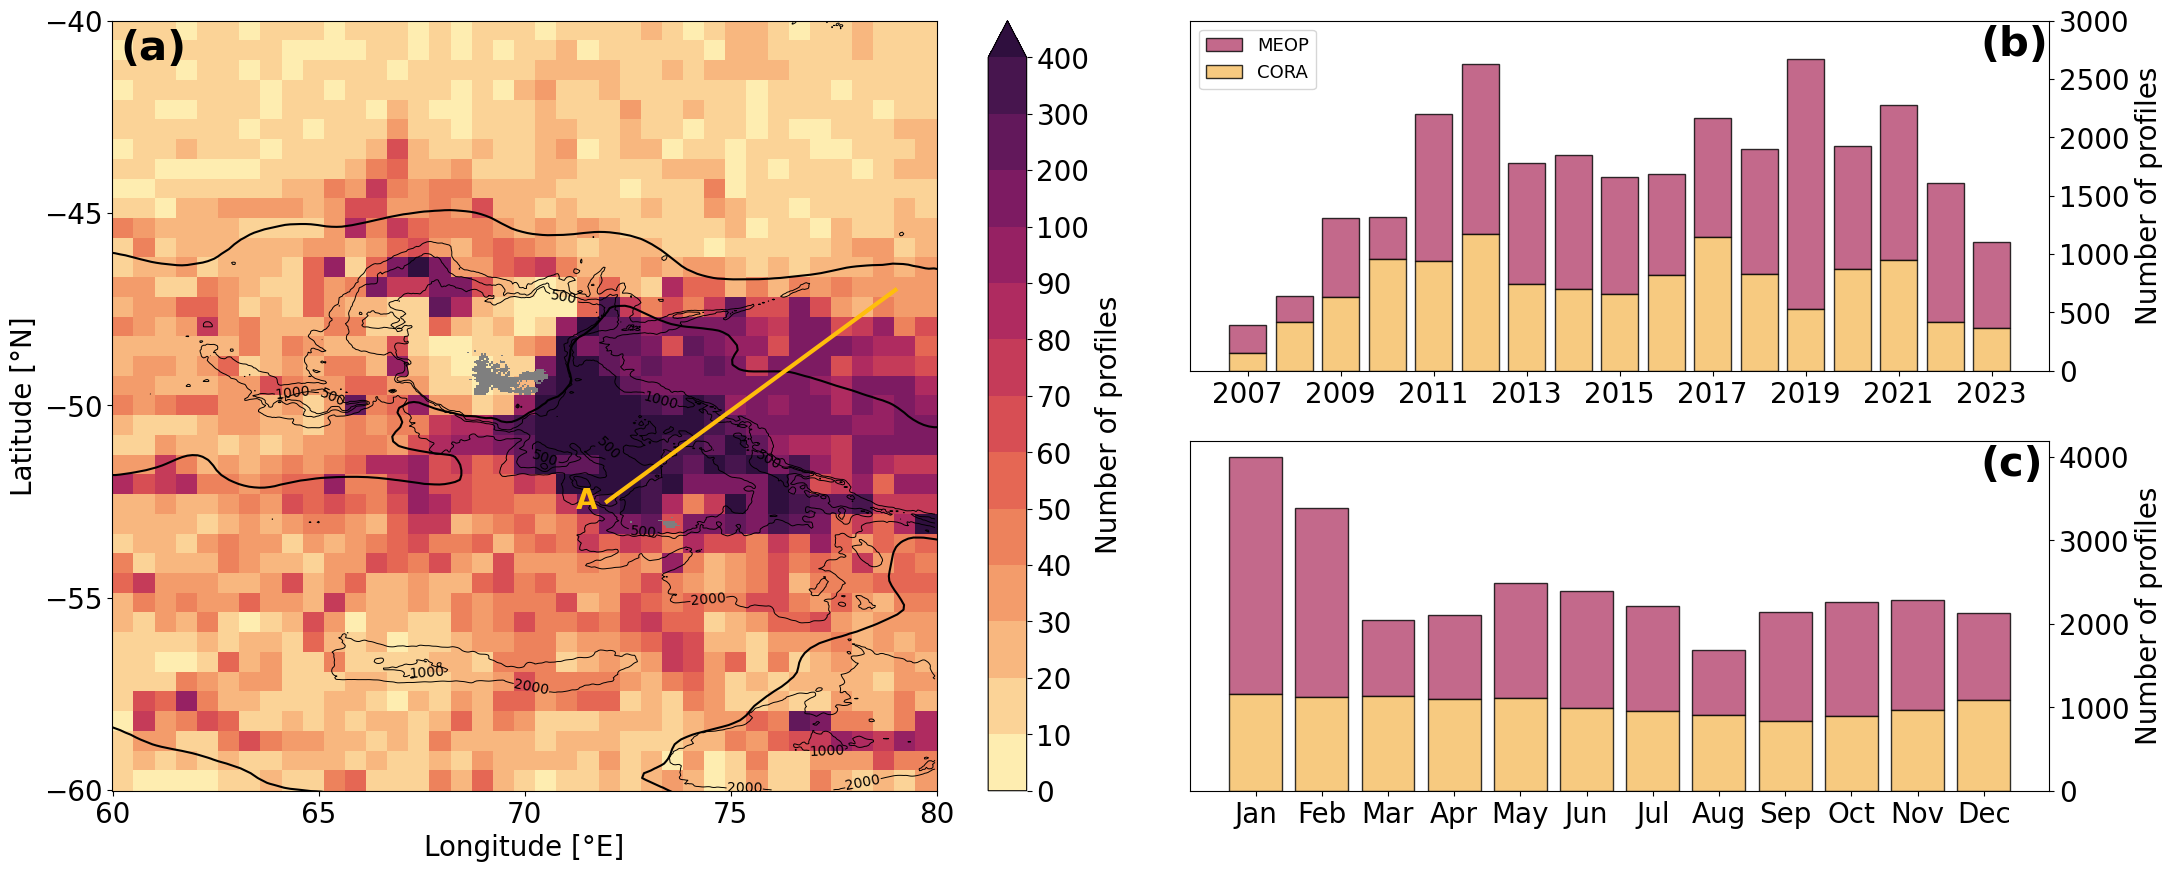

In [19]:
fig = plt.figure(figsize=(25, 10))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.2, 1],
    height_ratios=[1, 1],
    wspace=0.05, hspace=0.2
)

ax_map = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_year = fig.add_subplot(gs[0, 1])  # top-right
ax_month = fig.add_subplot(gs[1, 1]) # bottom-right

data_count = ds_count.sum("time").mld
MEOP_color = "#B5446E"
CORA_color = "#F6BD60"
# Discrete color levels
bounds_1 = np.arange(0, 100, 10)
bound_2 = np.arange(100, 500, 100)
bounds = np.concatenate((bounds_1, bound_2))

g = data_count.where(data_count > 0).plot(
    x="longitude", y="latitude",
    cmap=cmo.matter,
    levels=bounds,
    add_colorbar=False,
    ax=ax_map
)

(elevation / elevation).where(elevation > 0).plot(add_colorbar=False, cmap="gist_yarg", ax=ax_map)
CS = (-elevation).plot.contour(levels=(500, 1000, 2000), colors=["black"], linewidths=0.7, ax=ax_map)
ax_map.plot(ds_front.LonSAF.where(ds_front.LatSAF > -50), ds_front.LatSAF.where(ds_front.LatSAF > -50), c="k", label="SAF")
ax_map.plot(ds_front.LonPF, ds_front.LatPF, c="k", label="PF")
ax_map.plot(ds_front.LonSACCF, ds_front.LatSACCF, c="k", label="SACCF")

ax_map.clabel(CS, inline=True, fmt='%1.0f', fontsize=10)
ax_map.set_ylabel("Latitude [°N]")
ax_map.set_xlabel("Longitude [°E]")
ax_map.set_xticks([60, 65, 70, 75, 80])
ax_map.set_yticks([-60, -55, -50, -45, -40])
# ax_map.tick_params(labelsize=15)

cb = plt.colorbar(g, orientation="vertical", ax=ax_map, ticks=bounds)
cb.set_label(label='Number of profiles')
# cb.ax.tick_params(labelsize=15)

# Yearly counts (stacked)
hist_CORA = ds_count_CORA.count(["latitude", "longitude"]).groupby("time.year").sum().mld
hist_MEOP = ds_count_MEOP.count(["latitude", "longitude"]).groupby("time.year").sum().mld


all_years = np.arange(2007, 2024)
def reindex_to_years(da, years):
    return da.reindex(year=years, fill_value=0)

hist_CORA = reindex_to_years(hist_CORA, all_years)
hist_MEOP = reindex_to_years(hist_MEOP, all_years)


ax_year.bar(
    all_years, hist_MEOP.values,
    align="center", width=0.8, alpha=0.8,
    bottom=hist_CORA.values,
    color=MEOP_color, edgecolor="black", label="MEOP"
)

ax_year.bar(
    all_years, hist_CORA.values,
    align="center", width=0.8, alpha=0.8,
    color=CORA_color, edgecolor="black", label="CORA"
)

label_minor = np.arange(2005,2023,2)
month = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

ax_year.yaxis.tick_right()
ax_year.yaxis.set_label_position("right")
ax_year.set_ylabel("Number of profiles")
ax_year.xaxis.set_major_locator(ticker.FixedLocator(np.arange(2007, 2024, 2)))
ax_year.xaxis.set_minor_locator(ticker.FixedLocator(label_minor))
ax_year.set_ylim(0, 3000)
ax_year.legend(["MEOP","CORA"],fontsize=13,loc="upper left")

# Monthly counts (stacked)
hist_CORA_m = ds_count_CORA.count(["latitude", "longitude"]).groupby("time.month").sum().mld.reindex(month=np.arange(1, 13), fill_value=0)
hist_MEOP_m = ds_count_MEOP.count(["latitude", "longitude"]).groupby("time.month").sum().mld.reindex(month=np.arange(1, 13), fill_value=0)

months_idx = np.arange(1, 13)

ax_month.bar(
    months_idx, hist_MEOP_m.values,
    align="center", width=0.8, alpha=0.8,
    bottom=hist_CORA_m.values,
    color=MEOP_color, edgecolor="black", label="MEOP"
)

ax_month.bar(
    months_idx, hist_CORA_m.values,
    align="center", width=0.8, alpha=0.8,
    color=CORA_color, edgecolor="black", label="CORA"
)


ax_month.yaxis.tick_right()
ax_month.yaxis.set_label_position("right")
ax_month.set_ylabel("Number of profiles")
ax_month.set_xlabel("")
ax_month.set_xticks(months_idx)
ax_month.set_xticklabels(month)

# ### First cross section
# start_c = (70, -51.5)
# end_c = (75.5, -48)

### Second cross section
# start_c1 = (72, -52.5)
# end_c1 = (77.5, -49)

# ### Third cross section
# start_c2 = (74, -54)
# end_c2 = (79.5, -50.5)

# Draw 3 straight transects on the map
# ax_map.plot([start_c[0], end_c[0]], [start_c[1], end_c[1]], color="#FFBE0B", lw=3, zorder=6)
ax_map.plot([start_c1[0], end_c1[0]], [start_c1[1], end_c1[1]], color="#FFBE0B", lw=3, zorder=6)
# ax_map.plot([start_c2[0], end_c2[0]], [start_c2[1], end_c2[1]], color="#008DD5", lw=3, zorder=6)

for axes, n in zip([ax_map, ax_year, ax_month], ["(a)", "(b)", "(c)"]):
    if axes == ax_map:
        axes.text(0.01, 0.95, n, transform=axes.transAxes, weight='bold',fontsize=30)
    else:
        axes.text(0.92, 0.9, n, transform=axes.transAxes, weight='bold',fontsize=30)

# ax_map.annotate('C',
#                         xy=(75.5, -48),weight='bold',
#                         xytext=(0, 4),  # 4 points vertical offset.
#                         textcoords='offset points',
#                         ha='center', va='bottom',color="#FFBE0B",
#                         # bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2)
#                 )

ax_map.annotate('A',
                        xy=(start_c1[0]-0.5, start_c1[1]-0.5),weight='bold',
                        xytext=(0, 4),  # 4 points vertical offset.
                        textcoords='offset points',
                        ha='center', va='bottom',color="#FFBE0B",
                        # bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2)
                )

# ax_map.annotate('A',
#                         xy=(79.5, -50.5),weight='bold',
#                         xytext=(0, 4),  # 4 points vertical offset.
#                         textcoords='offset points',
#                         ha='center', va='bottom',color="#008DD5",
#                         # bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2)
#                 )

plt.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_1_prof_dist.png", bbox_inches="tight", dpi=300)